In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from linearmodels.panel import PanelOLS

import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer

In [14]:
data_dir = os.path.join('..', 'output')

df_shocks = pd.read_csv(os.path.join(data_dir, 'shocks_panel_wave_sendwave_gambia.csv'))
df_distance = pd.read_csv(os.path.join(data_dir, 'did_panel_distance.csv'))
df_savings= pd.read_csv(os.path.join(data_dir, 'did_panel_savings.csv'))

In [15]:
# Construct panel dataset 
df_panel = df_savings.copy()

if 'survey_year' not in df_panel.columns:
    raise ValueError("DataFrame must contain 'survey_year'.")

# Map macro shock years
shock_years = df_shocks.set_index('shock_name')['shock_year'].to_dict()

# Construct time-variant indicators (1 = post-shock, 0 = pre-shock)
df_panel['after_bceao_license'] = np.where(df_panel['survey_year'] >= shock_years.get('wave_bceao_eme_license', 2022), 1, 0)
df_panel['after_staff_cut_15pct'] = np.where(df_panel['survey_year'] >= shock_years.get('wave_staff_cut_15pct', 2022), 1, 0)
df_panel['after_debt_financing'] = np.where(df_panel['survey_year'] >= shock_years.get('wave_debt_financing_91m', 2022), 1, 0)
df_panel['after_gambia_launch'] = np.where(df_panel['survey_year'] >= shock_years.get('wave_gambia_launch', 2022), 1, 0)
df_panel['after_zepz_funding'] = np.where(df_panel['survey_year'] >= shock_years.get('zepz_funding_267m', 2024), 1, 0)
df_panel['after_expansion_funding'] = np.where(df_panel['survey_year'] >= shock_years.get('wave_expansion_funding_137m', 2025), 1, 0)

In [16]:
display(df_panel.head())

,hh_id,settlement,hh_savings,rural,survey_year,data_source,weight,hh_income,after_bceao_license,after_staff_cut_15pct,after_debt_financing,after_gambia_launch,after_zepz_funding,after_expansion_funding
0,1010101,"10,101.000",1,0,2015,IHS,18.111,3.000,0,0,0,0,0,0
1,1010103,"10,101.000",1,0,2015,IHS,18.111,2.000,0,0,0,0,0,0
2,1010104,"10,101.000",1,0,2015,IHS,18.111,2.000,0,0,0,0,0,0
3,1010105,"10,101.000",1,0,2015,IHS,18.111,2.000,0,0,0,0,0,0
4,1010106,"10,101.000",1,0,2015,IHS,18.111,1.000,0,0,0,0,0,0


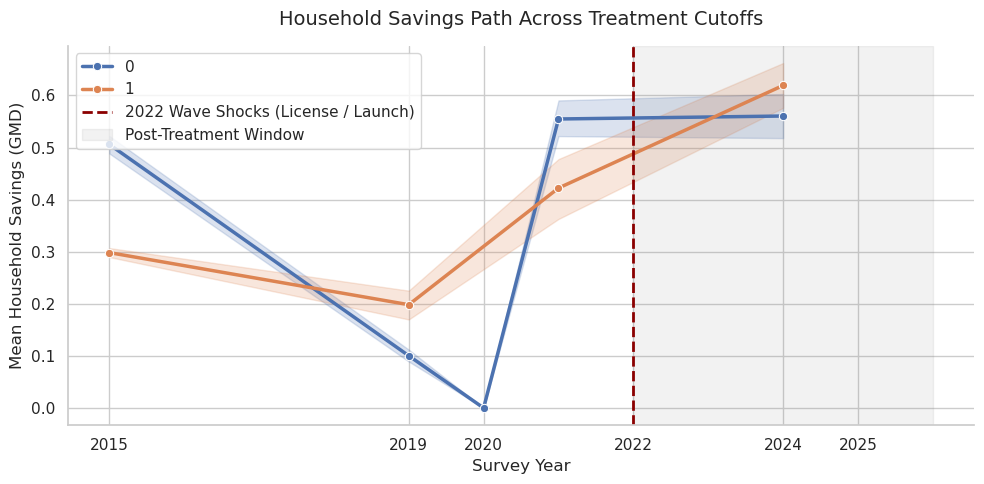

In [17]:
# Plot
# Set professional economics plot style
sns.set_theme(style='whitegrid', font='DejaVu Sans')
fig, ax = plt.subplots(figsize=(10, 5))

# Plot mean household savings trend line
sns.lineplot(
    data=df_panel, x='survey_year', y='hh_savings', 
    hue='rural', marker='o', linewidth=2.5, ax=ax
)

# Structural supply-side shock cutoff lines (2022 Cluster)
ax.axvline(x=2022, color='darkred', linestyle='--', linewidth=2, label='2022 Wave Shocks (License / Launch)')
ax.axvspan(2022, 2026, color='gray', alpha=0.1, label='Post-Treatment Window')

# Aesthetics
ax.set_title('Household Savings Path Across Treatment Cutoffs', fontsize=14, pad=15)
ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('Mean Household Savings (GMD)', fontsize=12)
ax.set_xticks([2015, 2019, 2020, 2022, 2024, 2025])
ax.legend(loc='upper left', frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

In [18]:
# summary table
econ_vars = ['hh_savings', 'hh_income']
summary_data = []

for var in econ_vars:
    row_mean = {'Variable': var, 'Metric': 'Mean'}
    row_se = {'Variable': var, 'Metric': 'Std. Error'}
    row_obs = {'Variable': var, 'Metric': 'Observations'}
    
    for group, label in [(0, 'Urban (0)'), (1, 'Rural (1)')]:
        sub = df_panel[df_panel['rural'] == group][var].dropna()
        
        row_mean[label] = sub.mean()
        row_se[label] = f"({stats.sem(sub):.3f})"  # Wrap SE in academic parentheses
        row_obs[label] = int(len(sub))
        
    summary_data.extend([row_mean, row_se, row_obs])

# Format into professional multi-index table
df_summary = pd.DataFrame(summary_data).set_index(['Variable', 'Metric'])

# Optional: Format floating points safely for the mixed table strings
pd.options.display.float_format = '{:,.3f}'.format
print(df_summary)

                        Urban (0) Rural (1)
Variable   Metric                          
hh_savings Mean             0.223     0.309
           Std. Error     (0.004)   (0.004)
           Observations     11873     11435
hh_income  Mean             2.687     2.222
           Std. Error     (0.012)   (0.009)
           Observations     11774     11383


In [21]:
# TWFE 1
# Fit the standard DiD model using clustered standard errors
model_did = smf.ols('hh_savings ~ rural * after_gambia_launch', data=df_panel).fit(
    cov_type='cluster', 
    cov_kwds={'groups': df_panel['hh_id']}
)

# Configure professional stargazer layout
stargazer = Stargazer([model_did])
stargazer.custom_columns(['Household Savings (GMD)'], [1])
stargazer.show_model_numbers(False)

# Clean academic variable mapping matching your image layout
stargazer.rename_covariates({
    'Intercept': 'Constant',
    'rural': 'Rural Sector (Baseline)',
    'after_gambia_launch': 'After Gambia Launch (Timeline Baseline)',
    'rural:after_gambia_launch': 'Rural $\\times$ After Gambia Launch (DiD Effect)'
})

stargazer